## **CleanSlate — Messy Dataset Cleanup**


# **🎯 Problem Statement**

A retail company stores customer information manually.

Over time, the dataset has become messy due to

- Missing values
- Duplicate records
- Wrong data types
- Inconsistent text values
Extra spaces
- Incorrect capitalization
- Salary increases by 10%
- Top 10 highest paid salary
- Top 3 Department bases on salary
- Adding a new visualisation way



As a Data Analyst, your task is to clean the dataset and generate useful business insights.

In [ ]:
# Import library
import numpy as np
import pandas as pd

In [ ]:
# Read dataset
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/CleanSlateMessyData.csv')

# **Step 1 - Inspect Dataset**

In [ ]:
# Step 1 - Inspect Dataset

In [ ]:
df.head()

,CustomerID,Name,Age,Gender,City,Salary,Department
0,1032,Vikas,51.0,MALE,Lucknow,39122.0,MARKETING
1,1110,Amit,56.0,FEMALE,Delhi,54961.0,MARKETING
2,1137,Rohan,42.0,FEMALE,Mumbai,70607.0,Marketing
3,1089,Neha,29.0,MALE,Jaipur,78574.0,it
4,1919,Neha,35.0,MALE,Delhi,118459.0,finance


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  1030 non-null   int64  
 1   Name        984 non-null    object 
 2   Age         980 non-null    float64
 3   Gender      1030 non-null   object 
 4   City        988 non-null    object 
 5   Salary      979 non-null    float64
 6   Department  1030 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 56.5+ KB


In [ ]:
df.describe(include = 'all')

,CustomerID,Name,Age,Gender,City,Salary,Department
count,1030.000000,984,980.000000,1030,988,979.000000,1030
unique,NaN,40,NaN,6,17,NaN,18
top,NaN,Neha,NaN,female,Bangalore,NaN,FINANCE
freq,NaN,62,NaN,200,126,NaN,69
mean,1502.901942,NaN,39.728571,NaN,NaN,72369.727273,NaN
std,289.078041,NaN,11.438864,NaN,NaN,28090.786074,NaN
min,1001.000000,NaN,20.000000,NaN,NaN,25112.000000,NaN
25%,1252.250000,NaN,30.000000,NaN,NaN,48223.500000,NaN
50%,1505.500000,NaN,40.000000,NaN,NaN,70607.000000,NaN
75%,1752.750000,NaN,50.000000,NaN,NaN,96268.500000,NaN


In [ ]:
df.shape

(1030, 7)

In [ ]:
df.columns

Index(['CustomerID', 'Name', 'Age', 'Gender', 'City', 'Salary', 'Department'], dtype='object')

# **Step 2 - Find Missing Values**

In [ ]:
# Step 2 - Find Missing Values
df.isna().sum()

,0
CustomerID,0
Name,46
Age,50
Gender,0
City,42
Salary,51
Department,0


# **Step 3 - Fill Missing Values**

In [ ]:
df['Age'].mean()

np.float64(39.72857142857143)

In [ ]:
# Age
df['Age'].fillna(39.7)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
# Salary
df['Salary'].median()

70607.0

In [ ]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [ ]:
# Name
df['Name'] = df['Name'].fillna('Unknown')

In [ ]:
# City
df['City'].mode()[0]

'Bangalore'

In [ ]:
df['City'] = df['City'].fillna(df['City'].mode()[0])

In [ ]:
df.isna().sum()

,0
CustomerID,0
Name,0
Age,50
Gender,0
City,0
Salary,0
Department,0


# **Step 4 - Remove Duplicates**

In [ ]:
# Step 4 - Remove Duplicates
df.duplicated().sum()

np.int64(30)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(1000, 7)

# **Step 5 - Standardize Text**

In [ ]:
# Gender
df['Gender'] = df['Gender'].str.capitalize()

In [ ]:
# City
df['City'] = df['City'].str.strip()

In [ ]:
# Department
df['Department'] = df['Department'].str.upper()

# **Step 6 Rename Columns**

In [ ]:
df.columns

Index(['CustomerID', 'Name', 'Age', 'Gender', 'City', 'Salary', 'Department'], dtype='object')

In [ ]:
{'Salary':'MonthlySalary'}

{'Salary': 'MonthlySalary'}

In [ ]:
# df.rename()
df.rename(columns={'Salary':'MonthlySalary'},inplace=True)

In [ ]:
df.columns

Index(['CustomerID', 'Name', 'Age', 'Gender', 'City', 'MonthlySalary',
       'Department'],
      dtype='object')

In [ ]:
df.MonthlySalary

,MonthlySalary
0,39122.0
1,54961.0
2,70607.0
3,78574.0
4,118459.0
...,...
1025,117764.0
1026,26481.0
1027,70607.0
1028,109700.0


MonthlySalary increases by 10%**

In [ ]:
#MonthlySalary increases by 10%
df['MonthlySalary']*1.1

,MonthlySalary
0,43034.2
1,60457.1
2,77667.7
3,86431.4
4,130304.9
...,...
1025,129540.4
1026,29129.1
1027,77667.7
1028,120670.0


# **Step 7 - Filter Dataset**

In [ ]:
# Employees with salary above 55,000
df['MonthlySalary']>55000

,MonthlySalary
0,False
1,False
2,True
3,True
4,True
...,...
1025,True
1026,False
1027,True
1028,True


In [ ]:
df[df['MonthlySalary']>55000]

,CustomerID,Name,Age,Gender,City,MonthlySalary,Department
2,1137,Rohan,42.0,Female,Mumbai,70607.0,MARKETING
3,1089,Neha,29.0,Male,Jaipur,78574.0,IT
4,1919,Neha,35.0,Male,Delhi,118459.0,FINANCE
5,1236,Rahul,35.0,Female,Mumbai,89425.0,SALES
6,1871,Vikas,40.0,Female,Bangalore,56709.0,HR
...,...,...,...,...,...,...,...
1024,1872,Neha,32.0,Female,Hyderabad,72788.0,FINANCE
1025,1088,Rahul,26.0,Male,Mumbai,117764.0,FINANCE
1027,1467,Sanjana,NaN,Female,Chennai,70607.0,SALES
1028,1122,Sanjana,51.0,Male,Bangalore,109700.0,OPERATIONS


In [ ]:
# Sales Department
df['Department']=='SALES'

,Department
0,False
1,False
2,False
3,False
4,False
...,...
1025,False
1026,False
1027,True
1028,False


In [ ]:
df[df['Department']=='SALES']

,CustomerID,Name,Age,Gender,City,MonthlySalary,Department
5,1236,Rahul,35.0,Female,Mumbai,89425.0,SALES
17,1665,Rakesh,53.0,Male,Delhi,71313.0,SALES
25,1322,Sneha,53.0,Male,Hyderabad,70607.0,SALES
26,1630,Sanjana,27.0,Male,Lucknow,57854.0,SALES
27,1915,Ankit,29.0,Female,Bangalore,75357.0,SALES
...,...,...,...,...,...,...,...
1000,1511,Riya,NaN,Female,Delhi,111346.0,SALES
1001,1059,Priya,42.0,Female,Jaipur,33155.0,SALES
1014,1386,Sanjana,51.0,Male,Chennai,76913.0,SALES
1017,1492,Arjun,33.0,Male,Chennai,87956.0,SALES


# **Step 8 - Analysis**

In [ ]:
# Average Salary
df['MonthlySalary'].mean()

np.float64(72423.77)

Top 10 largest paid salary

In [ ]:
#Top 10 largest paid salary
df.MonthlySalary.nlargest(10)

,MonthlySalary
1016,119876.0
76,119826.0
698,119803.0
784,119776.0
548,119767.0
826,119715.0
552,119636.0
945,119574.0
508,119426.0
729,119319.0


In [ ]:
# Department-wise Average Salary
df.groupby('Department')['MonthlySalary'].mean()

,MonthlySalary
Department,
FINANCE,69690.574586
HR,71439.261438
IT,71674.976331
MARKETING,73560.644578
OPERATIONS,74086.648045
SALES,74302.111842


Top 3 Departments based on Monthly Salary

In [ ]:
#Top 3 Department based on Average Salary
df.groupby('Department')['MonthlySalary'].mean().nlargest(3)

,MonthlySalary
Department,
SALES,74302.111842
OPERATIONS,74086.648045
MARKETING,73560.644578


In [ ]:
# City-wise Employees
df['City'].value_counts()

,count
City,
Bangalore,169
Hyderabad,130
Delhi,130
Pune,119
Chennai,116
Jaipur,110
Lucknow,109
Mumbai,109
nan,8


In [ ]:
# Average Age
df['Age'].mean()

np.float64(39.70842105263158)

# **Step 9 - Visualization**

<Axes: xlabel='Department'>

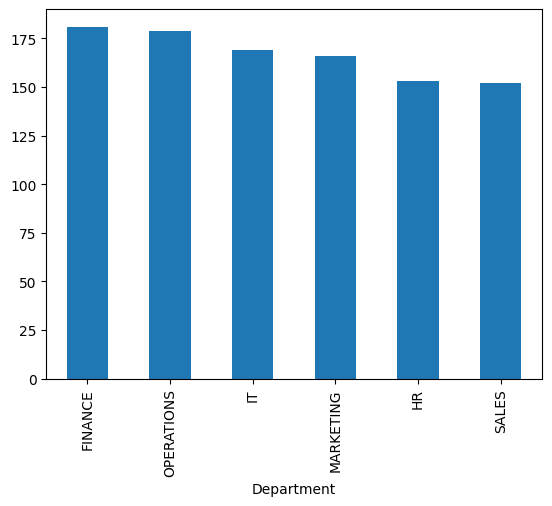

In [ ]:
# Department Count
df['Department'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

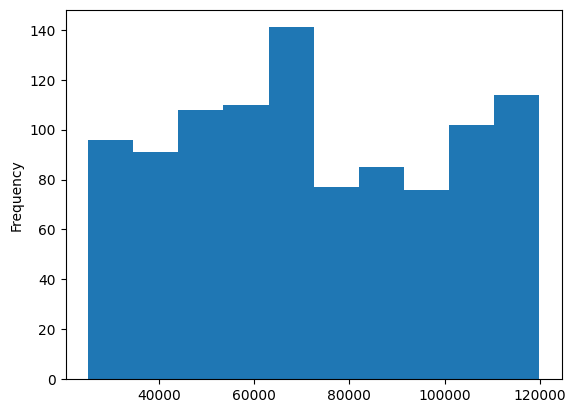

In [ ]:
# Salary Distribution
df['MonthlySalary'].plot(kind='hist')

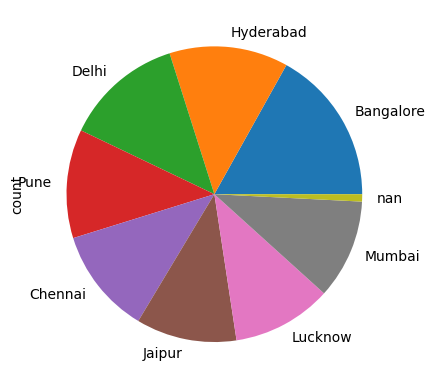

In [ ]:
# City Distribution
df['City'].value_counts().plot(kind='pie');

<Axes: >

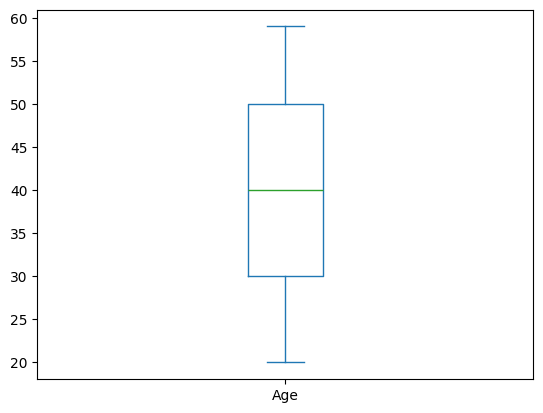

In [ ]:
#Age Distribution
df['Age'].plot(kind='box')

# **Step 10 - AutoEDA**

In [ ]:
!pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df,title='EDAReport')
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 26.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]